# Market Regime GMM vs HMM 

This notebook repeats the GMM vs HMM regime analysis using the BIC-preferred number of components from the model selection step.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

## 1. Load Settings

The factor proxies are ETFs that roughly represent broad macro market exposures.

In [2]:
from src.config import (
    COVARIANCE_TYPE,
    END_DATE,
    N_COMPONENTS,
    RANDOM_STATE,
    START_DATE,
    TICKERS,
)

TICKERS

{'Equity': 'ACWI',
 'Rates': 'IEF',
 'Credit': 'LQD',
 'Commodities': 'DBC',
 'EM': 'EEM',
 'FX': 'UUP',
 'ShortVol': 'PUTW',
 'Inflation': 'TIP'}

## 2. Download Adjusted Close Prices

Adjusted prices account for distributions and splits, which makes them better for return calculations.

In [3]:
from src.data import download_adjusted_prices

prices = download_adjusted_prices(TICKERS, START_DATE, END_DATE)
prices.head()

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
Date,,,,,,,,
2016-02-24,42.963634,87.790421,79.876762,10.669423,24.240389,21.127281,14.393457,83.979210
2016-02-25,43.425877,88.052399,80.323921,10.660969,24.320499,21.110573,14.453569,84.323486
2016-02-26,43.318565,87.623741,80.295937,10.644060,24.080177,21.252592,14.467878,84.106453
2016-02-29,43.087452,87.766609,80.351883,10.779329,24.288454,21.294361,14.433526,84.390862
2016-03-01,44.143993,87.080635,79.913925,10.787785,25.153612,21.302715,14.548031,84.158829


## 3. Compute Returns and Standardize

The model is fitted on daily log returns. Standardization puts all factors on a comparable scale.

In [4]:
from src.features import compute_log_returns, cumulative_returns, standardize_returns

returns = compute_log_returns(prices)
scaled_returns, scaler = standardize_returns(returns)

returns.tail()

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
Date,,,,,,,,
2026-05-20,0.012652,0.006743,0.007718,-0.023365,0.018502,-0.002161,0.003009,0.002359
2026-05-21,0.003797,0.000640,0.002036,-0.005846,0.008670,0.000000,0.001801,0.000000
2026-05-22,0.001925,0.000852,0.001847,-0.005225,-0.002274,0.001441,0.001049,0.000091
2026-05-26,0.011790,0.004252,0.003776,-0.016840,0.037538,-0.000720,0.002346,0.003978
2026-05-27,-0.001871,0.001537,0.001975,-0.018485,-0.001243,-0.001078,0.000000,0.000992


## GMM Model Selection

AIC and BIC compare GMM fits with different numbers of regimes. Lower values are preferred. In this notebook, the BIC-minimizing component count is used for both GMM and HMM.


In [5]:
import pandas as pd
from src.gmm_model import gmm_model_selection
from src.plots import plot_model_selection

gmm_selection = gmm_model_selection(
    scaled_returns,
    component_range=range(2, 7),
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)

# Use BIC component count
BIC_N_COMPONENTS = int(gmm_selection["BIC"].idxmin())
N_COMPONENTS = BIC_N_COMPONENTS
print(f"Using BIC-selected n_components = {N_COMPONENTS}")
gmm_selection.round(2)


Using BIC-selected n_components = 3


,AIC,BIC
n_components,,
2,38499.24,39020.32
3,37277.11,38061.65
4,37116.73,38164.73
5,37109.88,38421.35
6,37074.35,38649.28


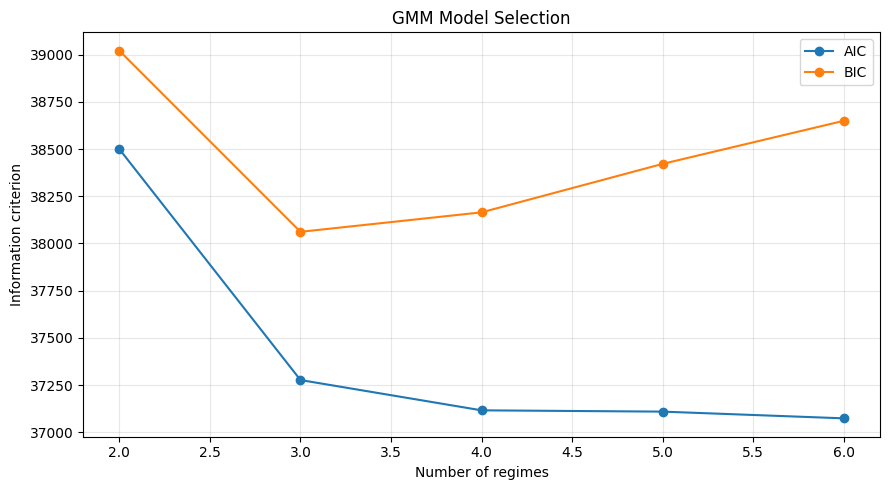

In [6]:
plot_model_selection(gmm_selection);

## 4. Fit the GMM

A Gaussian Mixture Model finds clusters of days with similar return patterns. Here we use the BIC-selected number of regimes.


In [7]:
from src.gmm_model import fit_gmm_regimes, validate_regime_outputs

gmm, labels, probabilities = fit_gmm_regimes(
    scaled_returns,
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)   

validate_regime_outputs(returns, labels, probabilities, N_COMPONENTS)
labels.value_counts().sort_index()

Regime
0     902
1    1608
2      68
Name: count, dtype: int64

## 5. Cumulative Return Chart

This shows how each factor proxy performed over the sample.

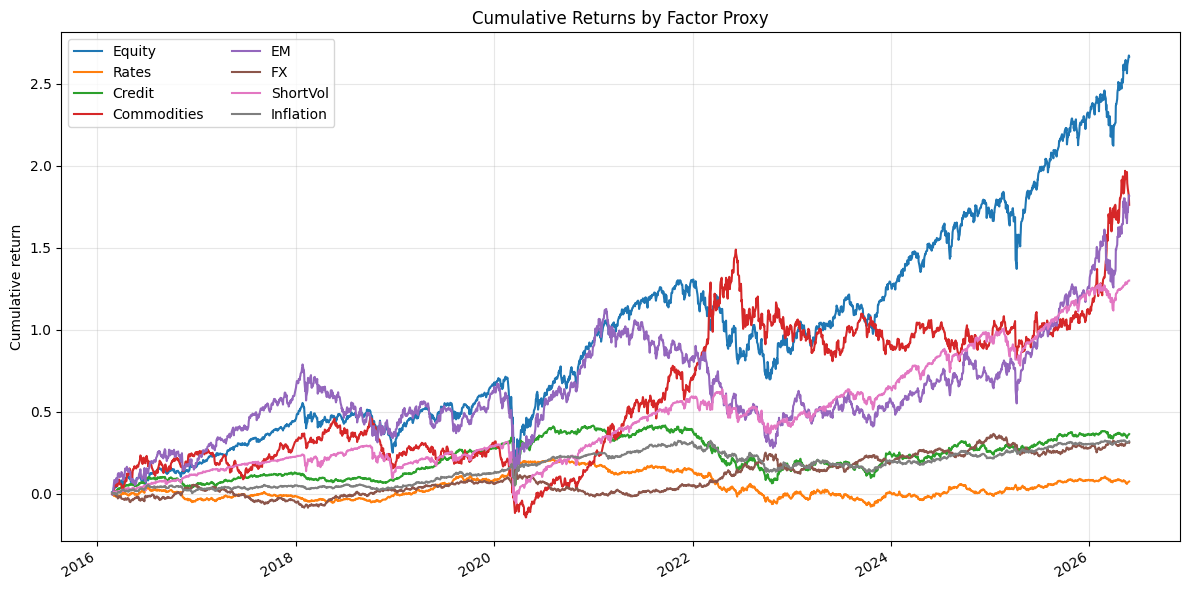

In [8]:
from src.plots import plot_cumulative_returns

plot_cumulative_returns(returns);

## 6. ACWI Colored by Regime

The model labels each day as one of four regimes. The numbers are model clusters, not economic names.

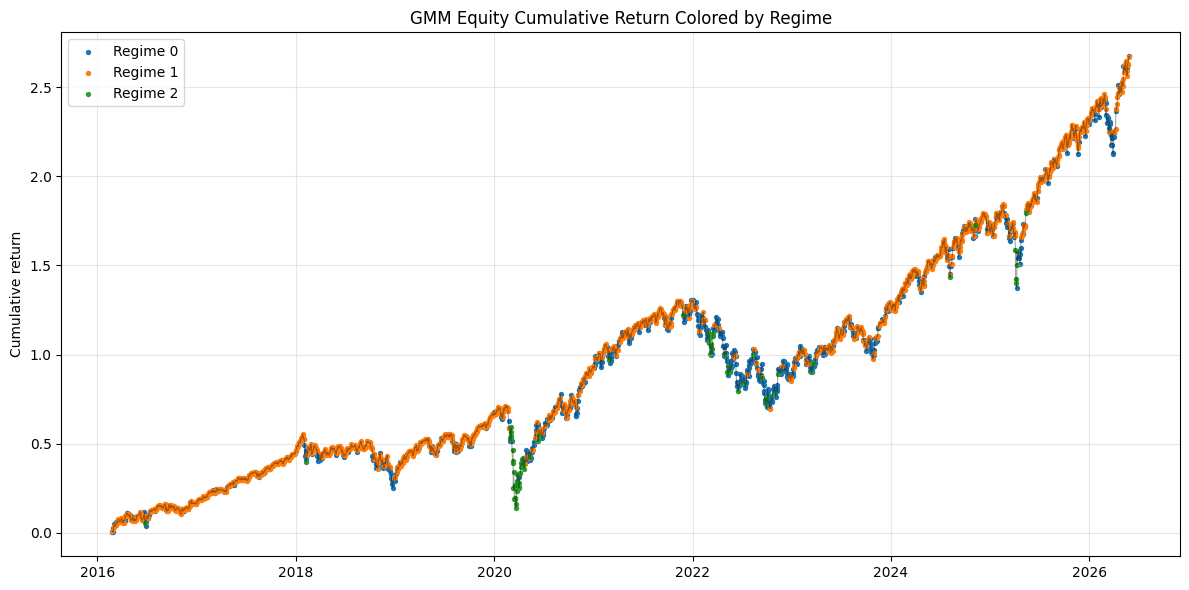

In [9]:
from src.plots import plot_regime_colored_series

cum_returns = cumulative_returns(returns)
plot_regime_colored_series(cum_returns, labels, column="Equity");

## 7. Regime Probability Chart

GMMs produce probabilities, not only hard labels. A high probability means the model is more confident about that regime on that day.

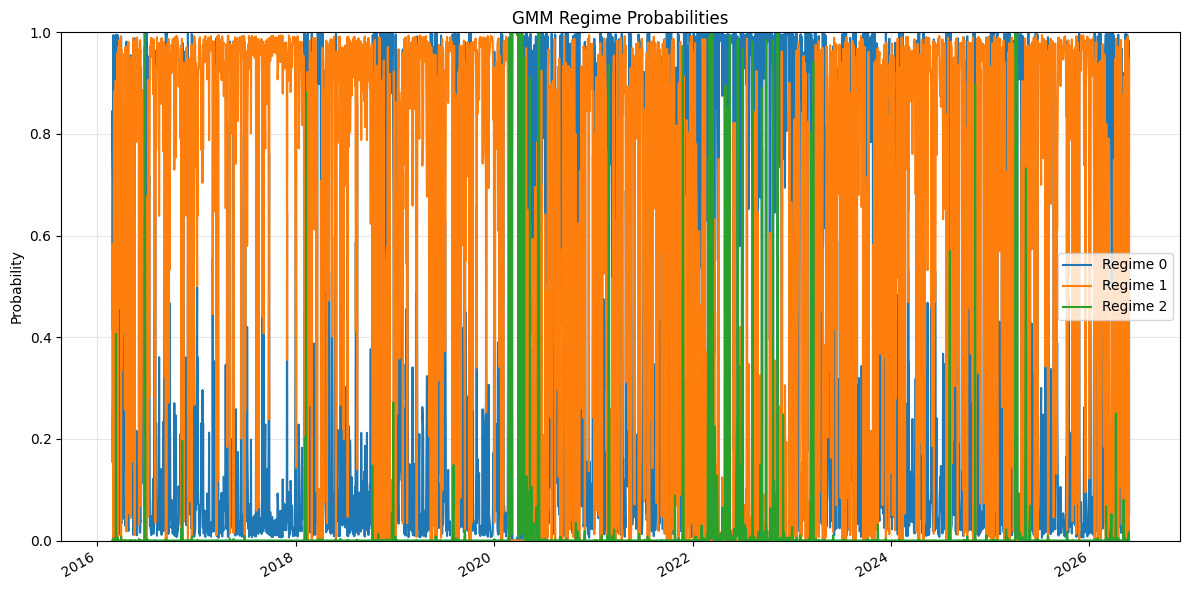

In [10]:
from src.plots import plot_regime_probabilities

plot_regime_probabilities(probabilities);

## 8. Regime Statistics

Use these tables to infer what each regime may mean economically.

In [11]:
from src.analysis import compact_interpretation_table, regime_correlations, regime_summary

summary = regime_summary(returns, labels)
interpretation = compact_interpretation_table(summary)
interpretation.round(4)

,Frequency,AvgCorrelation,Equity_Return,EM_Return,Rates_Return,Credit_Return,Commodities_Return,FX_Return,Inflation_Return,Equity_Volatility,Equity_Sharpe
Regime,,,,,,,,,,,
0,0.3499,0.1594,-0.0366,-0.0653,-0.0059,-0.0098,0.0051,0.0092,0.0115,0.2017,-0.1814
1,0.6237,0.1274,0.2823,0.2855,-0.0054,0.0442,0.2286,0.0320,0.0292,0.0785,3.5959
2,0.0264,0.2116,-1.3740,-2.0463,0.4765,0.2375,-1.7069,0.1273,0.1878,0.6443,-2.1326


## 9. Correlations by Regime

Correlation often rises during stressful markets. These heatmaps show how factor relationships differ by regime.

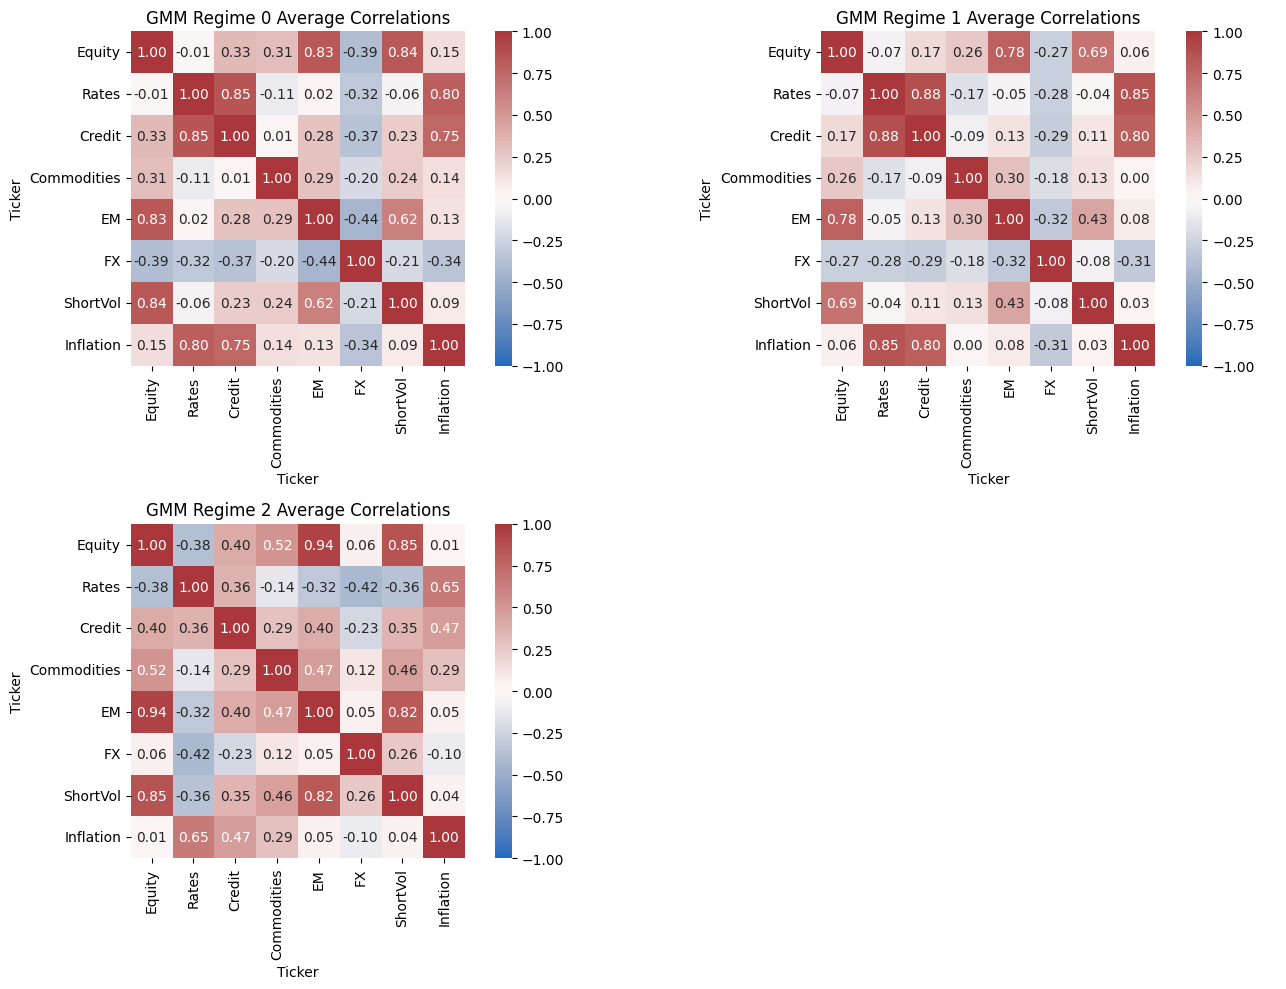

In [12]:
from src.plots import plot_factor_return_table, plot_factor_volatility_table, plot_regime_correlation_heatmaps

correlations = regime_correlations(returns, labels)
plot_regime_correlation_heatmaps(correlations);

## 10. Factor Volatility Table

This exhibit-style table compares annualized factor volatility across the four model regimes.

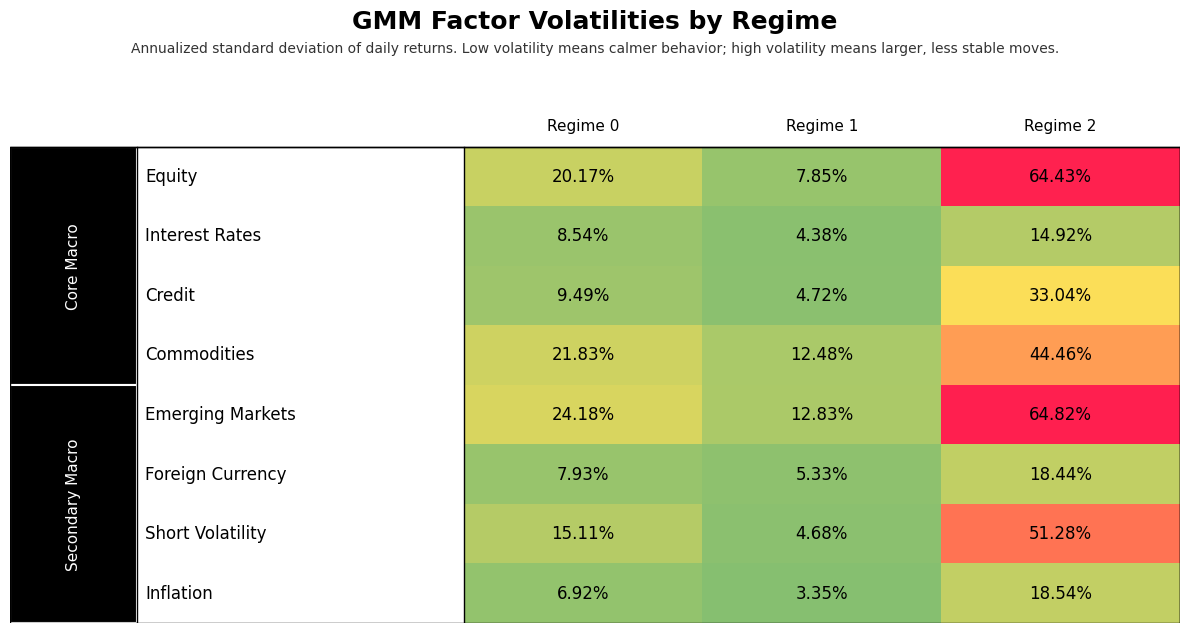

In [13]:
plot_factor_volatility_table(summary);

## 11. Factor Return Table

This table uses the same layout to compare annualized factor returns across regimes.

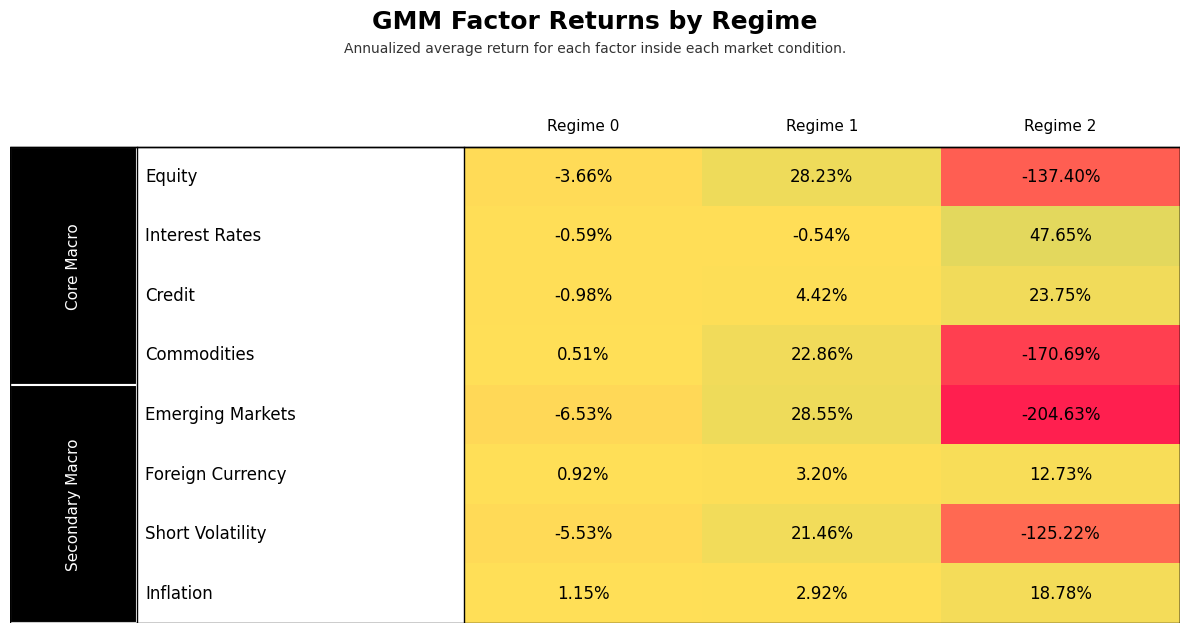

In [14]:
plot_factor_return_table(summary);

## Economic Interpretation Guide

Do not hardcode regime names. Instead, inspect each regime's return, volatility, frequency, and correlation profile.

- Weak equity and EM returns, high volatility, and high average correlations may suggest a crisis-like regime.
- Broad positive returns with lower volatility may suggest a calm regime.
- Strong commodities and inflation-linked bonds with weak nominal bonds may suggest inflationary pressure.
- Strong risk assets with elevated volatility may suggest speculative or high-volatility behavior.

The regime number itself has no permanent meaning. It is only the cluster ID assigned by the model.

## GMM Transition Diagnostics

These diagnostics show how often the static GMM labels switch from one regime to another.

In [15]:
from src.analysis import (
    regime_duration_stats,
    regime_performance_summary,
    transition_matrix,
)
from src.plots import plot_transition_heatmap

gmm_transition_counts = transition_matrix(labels, n_regimes=N_COMPONENTS, normalize=False)
gmm_transition_probabilities = transition_matrix(labels, n_regimes=N_COMPONENTS, normalize=True)
gmm_durations = regime_duration_stats(labels)
gmm_performance = regime_performance_summary(returns, labels)

gmm_transition_probabilities.round(3)

To,0,1,2
From,,,
0,0.553,0.411,0.035
1,0.230,0.768,0.002
2,0.500,0.029,0.471


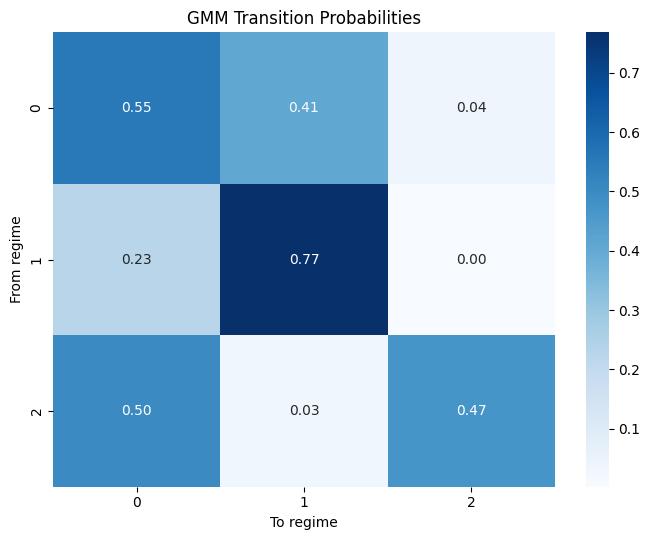

In [16]:
plot_transition_heatmap(
    gmm_transition_probabilities,
    title="GMM Transition Probabilities",
    fmt=".2f",
);

In [17]:
gmm_durations.round(2)

,Count,Mean,Median,Min,Max
Regime,,,,,
0,403,2.24,1.0,1,19
1,374,4.30,2.0,1,46
2,36,1.89,1.0,1,16


In [18]:
gmm_performance[gmm_performance["Factor"].eq("Equity")].round(4)

,Regime,Factor,AnnualReturn,AnnualVolatility,Sharpe,Observations
0,0,Equity,-0.0366,0.2017,-0.1814,902
8,1,Equity,0.2823,0.0785,3.5959,1608
16,2,Equity,-1.3740,0.6443,-2.1326,68


In [19]:
gmm_means = pd.DataFrame(gmm.means_, columns=scaled_returns.columns)
gmm_means.index.name = "Regime"
gmm_means.round(3)

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
Regime,,,,,,,,
0,-0.056,-0.011,-0.029,-0.031,-0.045,-0.016,-0.058,-0.014
1,0.060,-0.011,0.013,0.050,0.058,0.008,0.069,0.003
2,-0.464,0.372,0.127,-0.608,-0.562,0.051,-0.610,0.120


## Gaussian Hidden Markov Model

The HMM uses the same standardized return features, but estimates regimes with time-dependent transition probabilities.

In [20]:
from src.hmm_model import fit_hmm_regimes, validate_hmm_outputs

hmm, hmm_labels, hmm_probabilities = fit_hmm_regimes(
    scaled_returns,
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)
validate_hmm_outputs(returns, hmm_labels, hmm_probabilities, N_COMPONENTS)

hmm_labels.value_counts().sort_index()

HiddenState
0    1624
1     861
2      93
Name: count, dtype: int64

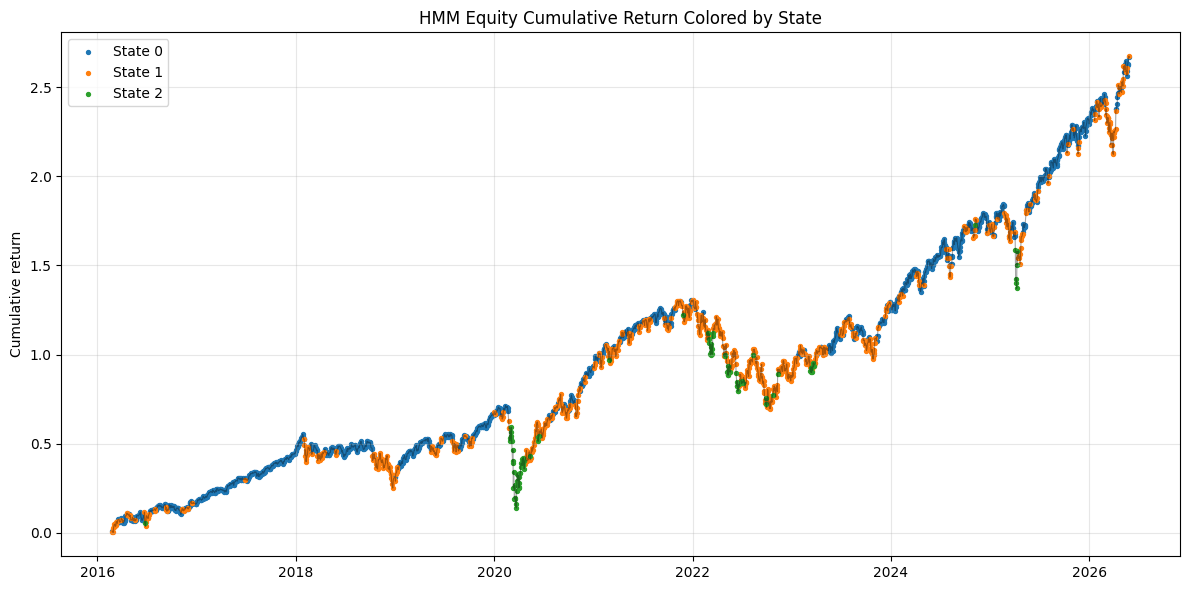

In [21]:
plot_regime_colored_series(cum_returns, hmm_labels, column="Equity");

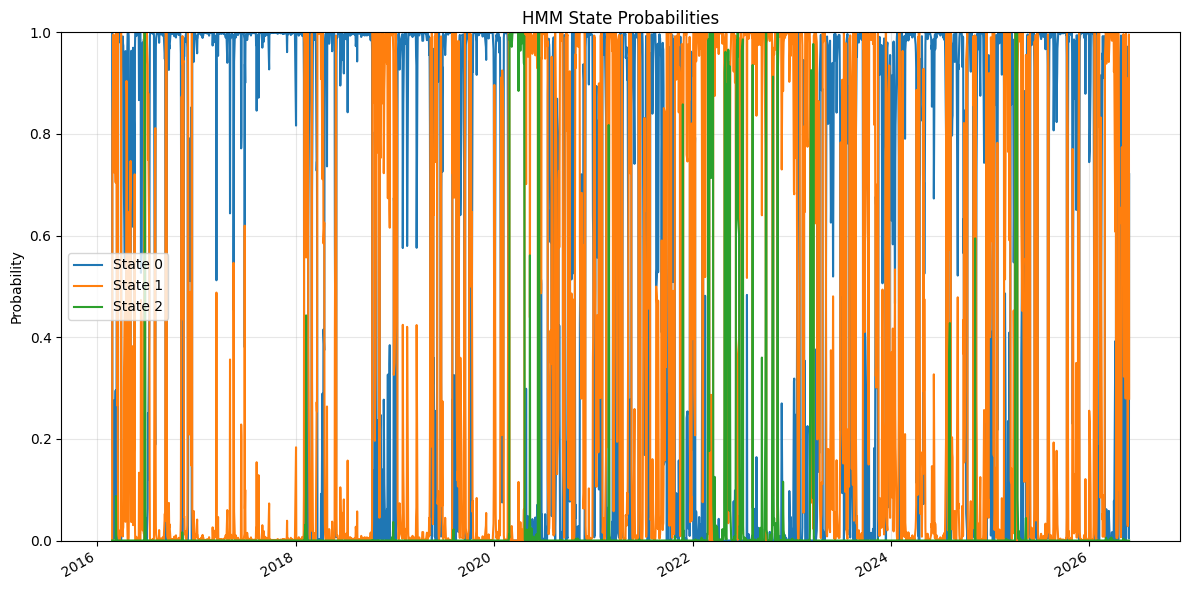

In [22]:
plot_regime_probabilities(hmm_probabilities);

In [23]:
hmm_means = pd.DataFrame(hmm.means_, columns=scaled_returns.columns)
hmm_means.index.name = "State"
hmm_means.round(3)

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
State,,,,,,,,
0,0.056,0.000,0.024,0.033,0.051,-0.003,0.062,0.013
1,-0.049,-0.038,-0.048,-0.000,-0.039,0.006,-0.050,-0.038
2,-0.461,0.354,0.053,-0.539,-0.473,-0.013,-0.539,0.135


## HMM Transition Diagnostics

The transition matrix is estimated directly by the HMM and summarizes state persistence.

In [24]:
hmm_transition_probabilities = pd.DataFrame(
    hmm.transmat_,
    index=range(N_COMPONENTS),
    columns=range(N_COMPONENTS),
)
hmm_transition_probabilities.index.name = "From"
hmm_transition_probabilities.columns.name = "To"

hmm_transition_counts = transition_matrix(hmm_labels, n_regimes=N_COMPONENTS, normalize=False)
hmm_durations = regime_duration_stats(hmm_labels)
hmm_performance = regime_performance_summary(returns, hmm_labels)

hmm_transition_probabilities.round(3)

To,0,1,2
From,,,
0,0.906,0.094,0.000
1,0.163,0.812,0.025
2,0.000,0.234,0.766


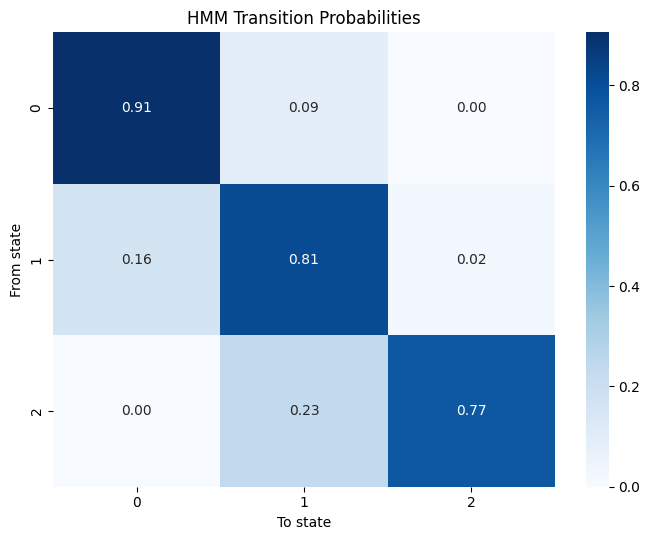

In [25]:
plot_transition_heatmap(
    hmm_transition_probabilities,
    title="HMM Transition Probabilities",
    fmt=".2f",
);

In [26]:
hmm_durations.round(2)

,Count,Mean,Median,Min,Max
Regime,,,,,
0,112,14.50,6.5,1,150
1,132,6.52,3.0,1,47
2,21,4.43,2.0,1,38


In [27]:
hmm_performance[hmm_performance["Factor"].eq("Equity")].round(4)

,Regime,Factor,AnnualReturn,AnnualVolatility,Sharpe,Observations
0,0,Equity,0.2845,0.0881,3.2294,1624
8,1,Equity,-0.0327,0.1965,-0.1663,861
16,2,Equity,-1.1440,0.5572,-2.0532,93


## GMM vs HMM Comparison

This compares the static GMM labels against the HMM hidden states on the same dates.

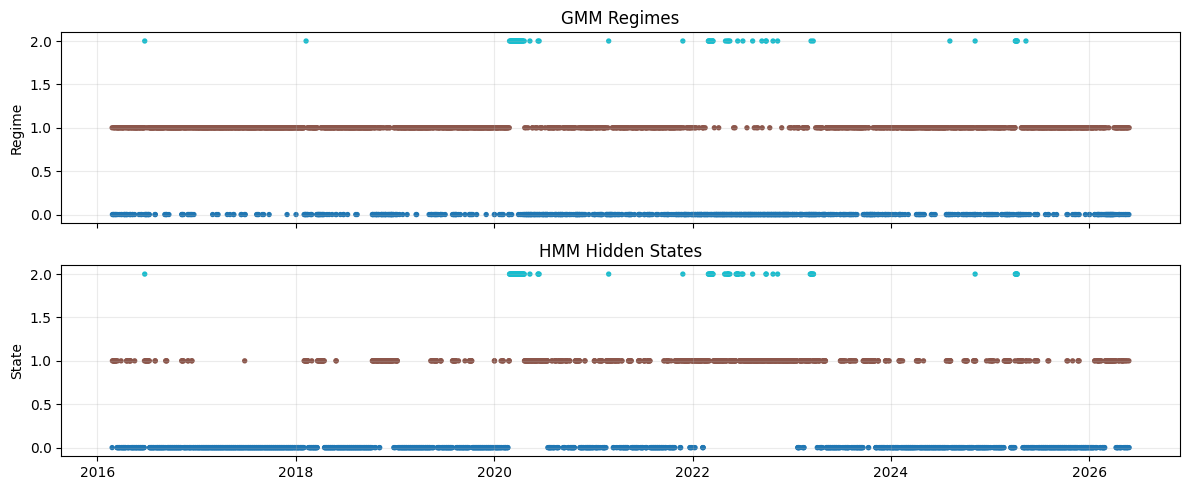

In [28]:
from src.analysis import label_confusion_matrix, persistence_table
from src.plots import plot_regime_timeline_comparison

plot_regime_timeline_comparison(labels, hmm_labels);

In [29]:
label_confusion_matrix(labels, hmm_labels).astype(int)

HMM,0,1,2
GMM,,,
0,161,712,29
1,1463,145,0
2,0,4,64


In [30]:
persistence_comparison = pd.DataFrame({
    "GMM_Label_Persistence": persistence_table(gmm_transition_probabilities)["Persistence"],
    "HMM_State_Persistence": persistence_table(hmm_transition_probabilities)["Persistence"],
})

persistence_comparison.round(3)

,GMM_Label_Persistence,HMM_State_Persistence
Regime,,
0,0.553,0.906
1,0.768,0.812
2,0.471,0.766


In [31]:
duration_comparison = pd.concat(
    {
        "GMM": gmm_durations["Mean"],
        "HMM": hmm_durations["Mean"],
    },
    axis=1,
)

duration_comparison.round(2)

,GMM,HMM
Regime,,
0,2.24,14.50
1,4.30,6.52
2,1.89,4.43


## Conclusions from BIC-Selected 3-Regime Model

AIC keeps improving up to 6 components, while BIC is lowest at 3 components. Since BIC penalizes complexity more strongly, the 3-regime model is the more statistically efficient choice here. Compared with the 4-regime version, the 3-regime setup gives a simpler interpretation: calm growth, weak/choppy conditions, and severe stress.

### GMM Regimes

| Regime | Possible Label | Finding |
|---|---|---|
| Regime 0 | Calm Growth | Most frequent regime; positive Equity and EM returns, low Equity volatility, and the strongest Sharpe. |
| Regime 1 | Choppy Slowdown | Mixed-to-weak regime; slightly negative Equity and EM returns, higher volatility, and near-flat Credit, Commodities, and Inflation. |
| Regime 2 | Defensive Stress | Rare severe-stress regime; very negative Equity, EM, Commodities, and ShortVol, but positive Rates, Credit, FX, and Inflation. |

### HMM States

| State | Possible Label | Finding |
|---|---|---|
| State 0 | Calm Growth | Main positive state; most observations, positive Equity/EM returns, low volatility, and strong Sharpe. |
| State 1 | Choppy Slowdown | Weak risk-off state; mildly negative Equity, EM, Credit, ShortVol, and Inflation, with moderate volatility. |
| State 2 | Defensive Stress | Severe stress state; very negative Equity, EM, Commodities, and ShortVol, with positive Rates and Inflation behavior. |

### GMM vs HMM

The main difference is persistence. The GMM still switches regimes more often because it clusters each day based on return patterns without modeling time dependence. The HMM produces smoother regimes because it estimates transition probabilities directly. This is clear from the persistence table: HMM self-transition probabilities are higher across all three states, and HMM average durations are longer than the equivalent GMM regimes.

Overall, the 3-regime version is easier to explain than the 4-regime version. Both GMM and HMM identify the same broad market structure: a calm growth regime, a weaker/choppy slowdown regime, and a defensive stress regime. The HMM gives the cleaner regime timeline because it treats market regimes as persistent hidden states rather than independent daily clusters.
